In [1]:
from pathlib import Path
import cv2
import numpy as np
import pyrealsense2 as rs

In [2]:
# Current folder should be:
# ./Data_preparation/realsense_bag_processing
BASE_DIR = Path.cwd()

if not (BASE_DIR / "realsense_raw_dataset").exists():
    candidate = BASE_DIR / "Data_preparation" / "realsense_bag_processing"
    if (candidate / "realsense_raw_dataset").exists():
        BASE_DIR = candidate

BAG_ROOT = BASE_DIR / "realsense_raw_dataset"
OUTPUT_ROOT = BASE_DIR / "bag_extracted_frames_aligned"

FRAME_INTERVAL = 10
SAVE_DEPTH_VIS = True

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("BAG_ROOT:", BAG_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("FRAME_INTERVAL:", FRAME_INTERVAL)
print("SAVE_DEPTH_VIS:", SAVE_DEPTH_VIS)

if not BAG_ROOT.exists():
    raise FileNotFoundError(f"Cannot find realsense_raw_dataset: {BAG_ROOT}")


BASE_DIR: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing
BAG_ROOT: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\realsense_raw_dataset
OUTPUT_ROOT: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned
FRAME_INTERVAL: 10
SAVE_DEPTH_VIS: True


In [3]:
bag_files = sorted(BAG_ROOT.glob("*.bag"))

print("Found bag files:", len(bag_files))
for i, bag in enumerate(bag_files):
    print(i, bag.name)

Found bag files: 8
0 20260304_161216.bag
1 20260304_161312.bag
2 20260304_161357.bag
3 20260304_161727.bag
4 20260304_161932.bag
5 20260304_162218.bag
6 20260304_162341.bag
7 20260304_162620.bag


In [4]:
test_bag_index = 0
bag_path = bag_files[test_bag_index]

print("Testing bag:", bag_path)

Testing bag: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\realsense_raw_dataset\20260304_161216.bag


In [5]:
def extract_aligned_rgb_depth_from_bag(
    bag_path: Path,
    output_root: Path,
    frame_interval: int = 10,
    save_depth_vis: bool = True
):
    bag_name = bag_path.stem
    bag_output_dir = output_root / bag_name

    color_dir = bag_output_dir / "color"
    depth_dir = bag_output_dir / "depth"
    depth_vis_dir = bag_output_dir / "depth_vis"

    color_dir.mkdir(parents=True, exist_ok=True)
    depth_dir.mkdir(parents=True, exist_ok=True)
    if save_depth_vis:
        depth_vis_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[INFO] Processing: {bag_path.name}")
    print(f"[INFO] Output dir: {bag_output_dir}")

    pipeline = rs.pipeline()
    config = rs.config()

    rs.config.enable_device_from_file(config, str(bag_path), repeat_playback=False)

    # Enable both streams
    config.enable_stream(rs.stream.color)
    config.enable_stream(rs.stream.depth)

    profile = pipeline.start(config)

    # Turn off real-time playback so frames won't be dropped
    playback = profile.get_device().as_playback()
    playback.set_real_time(False)

    # Align depth to color
    align = rs.align(rs.stream.color)

    frame_idx = 0
    saved_idx = 0

    try:
        while True:
            try:
                frames = pipeline.wait_for_frames()
            except RuntimeError:
                # End of bag
                break

            aligned_frames = align.process(frames)

            color_frame = aligned_frames.get_color_frame()
            depth_frame = aligned_frames.get_depth_frame()

            if not color_frame or not depth_frame:
                frame_idx += 1
                continue

            if frame_idx % frame_interval == 0:
                color_image = np.asanyarray(color_frame.get_data())
                depth_image = np.asanyarray(depth_frame.get_data())  # usually uint16

                # Convert RGB -> BGR for OpenCV save
                color_bgr = cv2.cvtColor(color_image, cv2.COLOR_RGB2BGR)

                base_name = f"{bag_name}_frame_{frame_idx:06d}"

                color_path = color_dir / f"{base_name}.jpg"
                depth_path = depth_dir / f"{base_name}.png"

                cv2.imwrite(str(color_path), color_bgr)
                cv2.imwrite(str(depth_path), depth_image)

                if save_depth_vis:
                    depth_vis = cv2.convertScaleAbs(depth_image, alpha=0.03)
                    depth_vis = cv2.applyColorMap(depth_vis, cv2.COLORMAP_JET)
                    depth_vis_path = depth_vis_dir / f"{base_name}.jpg"
                    cv2.imwrite(str(depth_vis_path), depth_vis)

                saved_idx += 1

            frame_idx += 1

    finally:
        pipeline.stop()

    print(f"[INFO] Total frames read : {frame_idx}")
    print(f"[INFO] Frames saved      : {saved_idx}")
    print(f"[INFO] Saved color dir   : {color_dir}")
    print(f"[INFO] Saved depth dir   : {depth_dir}")
    if save_depth_vis:
        print(f"[INFO] Saved depth_vis   : {depth_vis_dir}")

In [6]:
extract_aligned_rgb_depth_from_bag(
    bag_path=bag_path,
    output_root=OUTPUT_ROOT,
    frame_interval=FRAME_INTERVAL,
    save_depth_vis=SAVE_DEPTH_VIS
)


[INFO] Processing: 20260304_161216.bag
[INFO] Output dir: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216
[INFO] Total frames read : 1014
[INFO] Frames saved      : 102
[INFO] Saved color dir   : C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216\color
[INFO] Saved depth dir   : C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216\depth
[INFO] Saved depth_vis   : C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216\depth_vis


In [7]:
test_output_dir = OUTPUT_ROOT / bag_path.stem
print("Output folder:", test_output_dir)

for p in test_output_dir.iterdir():
    print(p.name)

Output folder: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216
color
depth
depth_vis


In [8]:
color_dir = test_output_dir / "color"
depth_dir = test_output_dir / "depth"
depth_vis_dir = test_output_dir / "depth_vis"

color_files = sorted(color_dir.glob("*.jpg"))
depth_files = sorted(depth_dir.glob("*.png"))
depth_vis_files = sorted(depth_vis_dir.glob("*.jpg"))

print("Color files:", len(color_files))
print("Depth files:", len(depth_files))
print("Depth vis files:", len(depth_vis_files))

sample_idx = 0
color_path = color_files[sample_idx]
depth_path = depth_files[sample_idx]
depth_vis_path = depth_vis_files[sample_idx]

print("Sample color:", color_path.name)
print("Sample depth:", depth_path.name)
print("Sample depth vis:", depth_vis_path.name)

Color files: 102
Depth files: 102
Depth vis files: 102
Sample color: 20260304_161216_frame_000000.jpg
Sample depth: 20260304_161216_frame_000000.png
Sample depth vis: 20260304_161216_frame_000000.jpg


Color shape: (480, 640, 3)
Depth shape: (480, 640) dtype: uint16
Depth vis shape: (480, 640, 3)


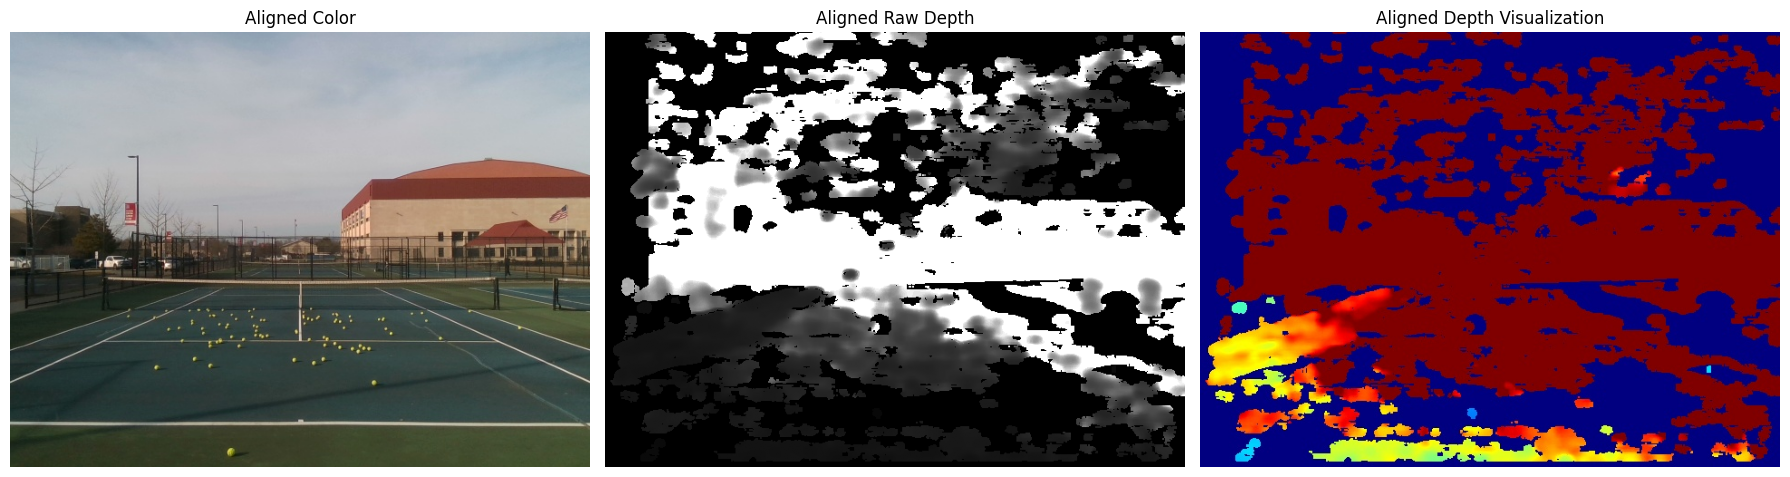

In [9]:
import matplotlib.pyplot as plt

color_bgr = cv2.imread(str(color_path))
color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)

depth_raw = cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED)
depth_vis_bgr = cv2.imread(str(depth_vis_path))
depth_vis_rgb = cv2.cvtColor(depth_vis_bgr, cv2.COLOR_BGR2RGB)

print("Color shape:", color_rgb.shape)
print("Depth shape:", depth_raw.shape, "dtype:", depth_raw.dtype)
print("Depth vis shape:", depth_vis_rgb.shape)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(color_rgb)
plt.title("Aligned Color")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(depth_raw, cmap="gray")
plt.title("Aligned Raw Depth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(depth_vis_rgb)
plt.title("Aligned Depth Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
for bag_path in bag_files:
    extract_aligned_rgb_depth_from_bag(
        bag_path=bag_path,
        output_root=OUTPUT_ROOT,
        frame_interval=FRAME_INTERVAL,
        save_depth_vis=SAVE_DEPTH_VIS
    )


[INFO] Processing: 20260304_161216.bag
[INFO] Output dir: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216
[INFO] Total frames read : 1014
[INFO] Frames saved      : 102
[INFO] Saved color dir   : C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216\color
[INFO] Saved depth dir   : C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216\depth
[INFO] Saved depth_vis   : C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161216\depth_vis

[INFO] Processing: 20260304_161312.bag
[INFO] Output dir: C:\Users\Xinyang\Desktop\AdvDeepLearning\Data_preparation\realsense_bag_processing\bag_extracted_frames_aligned\20260304_161312
[INFO] Total frames read : 429
[INFO] Frames saved      : 43
[INFO] Saved co